# Causal-prior FasterRisk on synthetic linear-Gaussian DAGs

Modified FasterRisk with a soft causal-prior penalty, tested on synthetic data where the true support $S^*$ and the causal partition are known. Each cell is a combination of $p$, $n$, $k^*$, $p_\mathrm{edge}$, run over 20 seeds with $K = 2 k^*$ and $\mu$ on a log grid relative to the median data gradient.

Five $q$ sources: GES (causal discovery via R-pcalg), bootstrap-$L_1$ (predictive stability), uniform (no preference, equivalent to vanilla FR), adversarial (q on confounders only), and oracle (hard $S^*$ membership, kept out of the headlines as a non-operational reference). PC was tested but Fisher-Z on dense Gaussian DAGs returns near-noise q, so it is omitted.

Recovery metrics. $S^*$ is the set of direct parents of $Y$. Given $S^*$, $Y$ is independent of the indirect causes, so $S^*$ is the minimal sufficient predictor set and the target a sparse scorecard should aim for. The support is scored three ways:

- `S_precision` (primary): fraction of selected features in $S^*$. Separates causal $q$ from predictive $q$ across densities.
- `correlate_inclusion` (lower is better): fraction of selections that are non-causal correlates (descendants of causes, common-effect structure). Measures confounder avoidance.
- `causal_precision` (diagnostic): fraction that are any cause, direct or indirect (ancestors of $Y$). Saturates at high density, where almost every node is an ancestor of $Y$.

The cause-aware columns are computed from the stored supports by `loading.add_causal_metrics`, with no refit.

The noise sweep ($\sigma_\mathrm{noise} \in \{0.5, 1.0, 2.0\}$) only added cells at the anchor. The non-noise slices below filter to $\sigma_\mathrm{noise}=1.0$ so the anchor point in each axis keeps a single sample size; `noise_sweep` and `noise_cv` keep all three for the SNR panel.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parents[2]))

from src.causal_prior.loading import load_recovery_csvs
from src.causal_prior import visualization as viz

ROOT = Path.cwd().parents[2]
recovery = load_recovery_csvs(ROOT / 'results/causal_prior/synthetic/recovery_p30_headline')

In [2]:
recovery = recovery[~recovery['q_source'].str.startswith('pc')]
recovery = recovery[recovery['q_source'] != 'oracle']

default_noise = recovery['noise_scale'] == 1.0
pe_sweep    = recovery[default_noise].query('p == 30 and n == 300 and k_star == 5')        # vary p_edge
n_sweep     = recovery[default_noise].query('p == 30 and k_star == 5 and p_edge == 0.2')   # vary n
p_sweep     = recovery[default_noise].query('n == 300 and k_star == 5 and p_edge == 0.2')  # vary p
k_sweep     = recovery[default_noise].query('p == 30 and n == 300 and p_edge == 0.2')      # vary k_star
noise_sweep = recovery.query('p == 30 and n == 300 and k_star == 5 and p_edge == 0.2')     # vary noise

In [3]:
cv = load_recovery_csvs(ROOT / 'results/causal_prior/synthetic/recovery_cv')  # fresh 20-seed sweep, includes iamb
cv = cv[~cv['q_source'].str.startswith('pc')]
cv = cv[cv['q_source'] != 'oracle']

default_noise = cv['noise_scale'] == 1.0
pe_cv    = cv[default_noise].query('p == 30 and n == 300 and k_star == 5')        # vary p_edge
n_cv     = cv[default_noise].query('p == 30 and k_star == 5 and p_edge == 0.2')   # vary n
p_cv     = cv[default_noise].query('n == 300 and k_star == 5 and p_edge == 0.2')  # vary p
k_cv     = cv[default_noise].query('p == 30 and n == 300 and p_edge == 0.2')      # vary k_star
noise_cv = cv.query('p == 30 and n == 300 and k_star == 5 and p_edge == 0.2')     # vary noise

## Headline: minimal causal recovery and confounder avoidance

For each cell and $q$ source, $\hat{\mu}$ is picked by 5-fold CV on log-loss, the model is refit on full data, and the support is scored against the causal partition. Anchor cell $p=30, n=300, k^*=5$; vanilla (uniform $q$) is the no-prior reference. Two metrics cover two separate claims.

Minimal causal recovery (`S_precision`, first panel): fraction of selected features that are direct parents $S^*$. GES is above bootstrap-$L_1$, which is above vanilla, at every density, and the gap widens with $p_\mathrm{edge}$. GES minus vanilla goes from +0.14 at $p_\mathrm{edge}=0.1$ to about +0.20 to +0.29 for $p_\mathrm{edge}\geq 0.3$, with GES 0.32, $L_1$ 0.18, vanilla 0.12 at $p_\mathrm{edge}=0.7$.

Confounder avoidance (`correlate_inclusion`, second panel, lower is better): fraction of selections that are non-causal correlates. GES selects about 0.07 to 0.09 fewer correlates than vanilla at $p_\mathrm{edge}=0.1$ to $0.2$ (paired $t \approx 2$ to $4$), and the gap closes by $p_\mathrm{edge}\geq 0.3$ because the correlate set shrinks: at $p_\mathrm{edge}=0.7$ only about 5 of 30 features are non-causal, against about 20 indirect causes.

Reading the two together: at high density `S_precision` keeps separating the sources while `causal_precision` (third panel) saturates near 1.0, since almost every node is a cause. So the high-density `S_precision` gap reflects a preference for direct over indirect causes, not avoidance of non-causal features. Genuine confounder avoidance is the low-density `correlate_inclusion` effect. The two metrics answer different questions.

<Axes: title={'center': '$p_{\\mathrm{edge}}$ sweep at CV-picked $\\hat{\\mu}$'}, xlabel='$p_{\\mathrm{edge}}$', ylabel='S precision'>

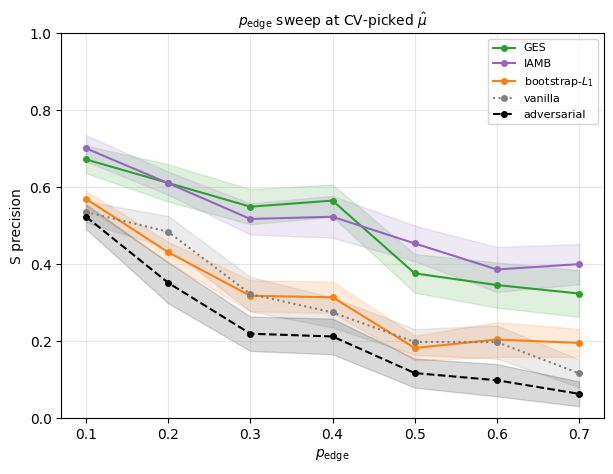

In [4]:
viz.plot_recovery_cv_vs_axis(pe_cv, axis_col='p_edge', metric='S_precision')

### Confounder-avoidance panel (`correlate_inclusion`, lower is better)

The headline cell scored by the fraction of selections that are non-causal correlates. GES is below vanilla at $p_\mathrm{edge}=0.1$ to $0.2$ (about 0.07 to 0.09 fewer correlates) and converges with the other sources at higher density as the correlate set shrinks.

<Axes: title={'center': '$p_{\\mathrm{edge}}$ sweep at CV-picked $\\hat{\\mu}$'}, xlabel='$p_{\\mathrm{edge}}$', ylabel='correlate inclusion'>

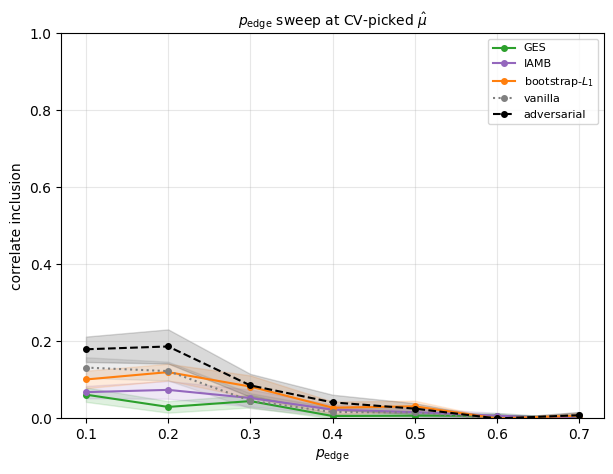

In [5]:
viz.plot_recovery_cv_vs_axis(pe_cv, axis_col='p_edge', metric='correlate_inclusion')

### Any-cause precision (`causal_precision`, diagnostic)

Fraction of selections that are any cause, direct or indirect. It follows `S_precision` at low density but saturates near 1.0 from $p_\mathrm{edge}\geq 0.3$, since at high density almost every node is an ancestor of $Y$. This is why the high-density `S_precision` gap reflects direct-versus-indirect cause selection rather than confounder avoidance: there are few non-causal features left to separate on.

<Axes: title={'center': '$p_{\\mathrm{edge}}$ sweep at CV-picked $\\hat{\\mu}$'}, xlabel='$p_{\\mathrm{edge}}$', ylabel='causal precision'>

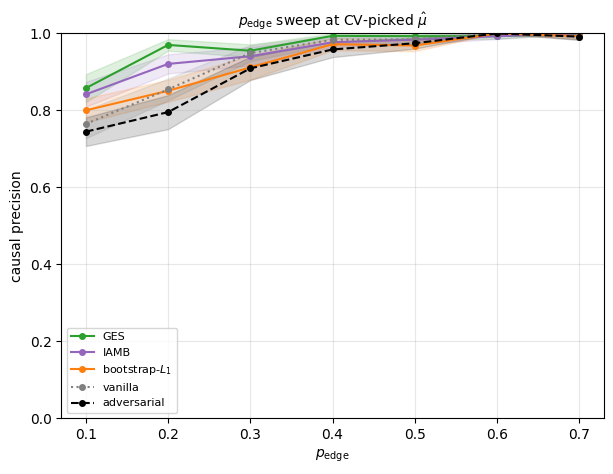

In [6]:
viz.plot_recovery_cv_vs_axis(pe_cv, axis_col='p_edge', metric='causal_precision')

## Diagnostic: $\hat{\mu}_\mathrm{CV}$ vs $p_\mathrm{edge}$

How the CV-picked strength moves with confounding density. Open markers flag cells where CV picked $\hat{\mu}=0$ (at least 50% of seeds collapsed to vanilla). GES stays nonzero across all $p_\mathrm{edge}$; vanilla and adversarial sit at the floor. The precision gap holds because $\hat{\mu}$ lands in the flat region of the $\mu$ grid.

<Axes: title={'center': 'CV-picked $\\mu$ vs $p_{\\mathrm{edge}}$'}, xlabel='$p_{\\mathrm{edge}}$', ylabel='$\\hat{\\mu}_{\\mathrm{rel}}$ (CV)'>

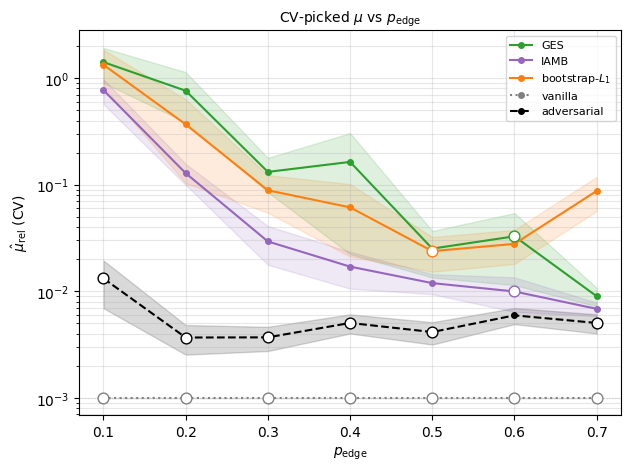

In [7]:
viz.plot_mu_star_vs_axis(pe_cv, axis_col='p_edge')

## Sample size

$n$ sweep at $p=30, k^*=5, p_\mathrm{edge}=0.2$, `S_precision` at CV-picked $\hat{\mu}$ (10 seeds, so noisier than the headline). GES minus vanilla rises from +0.08 at $n=75$ to +0.13 to +0.17 around $n=150$ to $300$, then falls to about 0 by $n=500$. At small $n$ discovery is too noisy to help; at large $n$ the data alone recovers $S^*$. The prior helps in the data-limited middle, which is where $n=164$ TB sits. `causal_precision` follows the same shape, +0.09 to +0.12 in the middle and about 0 by $n=500$.

<Axes: title={'center': '$n$ sweep at CV-picked $\\hat{\\mu}$'}, xlabel='$n$', ylabel='S precision'>

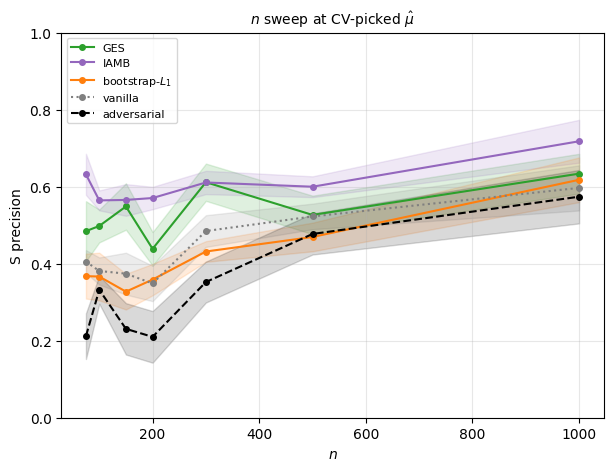

In [8]:
viz.plot_recovery_cv_vs_axis(n_cv, axis_col='n')

## Feature count

$p$ sweep at $n=300, k^*=5, p_\mathrm{edge}=0.2$, `S_precision`. GES minus vanilla is about 0 at $p=10$, +0.13 at $p=30$, +0.34 at $p=50$. More candidate features give the prior more room to steer the $K$ slots toward $S^*$. At $p=50$ `causal_precision` shows only +0.01, so most of the $p=50$ `S_precision` gain is direct-over-indirect cause selection (a denser graph has more indirect causes), not extra correlate avoidance.

<Axes: title={'center': '$p$ sweep at CV-picked $\\hat{\\mu}$'}, xlabel='$p$', ylabel='S precision'>

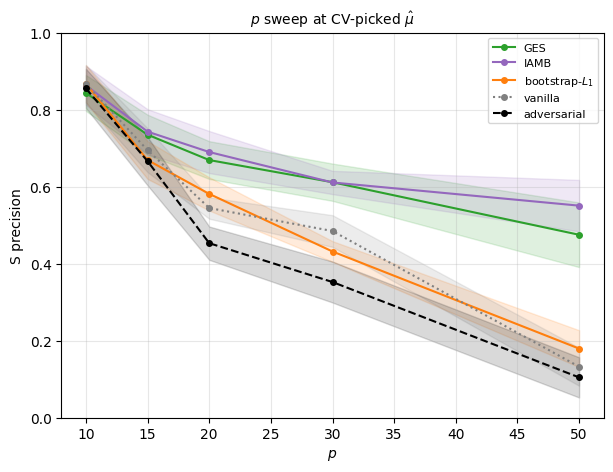

In [9]:
viz.plot_recovery_cv_vs_axis(p_cv, axis_col='p')

## Target sparsity

$k^*$ sweep at $p=30, n=300, p_\mathrm{edge}=0.2$, $K = 2 k^*$, `S_precision`. GES minus vanilla is +0.02, +0.13, +0.15 at $k^* \in \{3,5,7\}$. The effect holds across sparsities; `causal_precision` agrees (+0.07, +0.12, +0.07).

<Axes: title={'center': '$k^{*}$ sweep at CV-picked $\\hat{\\mu}$'}, xlabel='$k^{*}$', ylabel='S precision'>

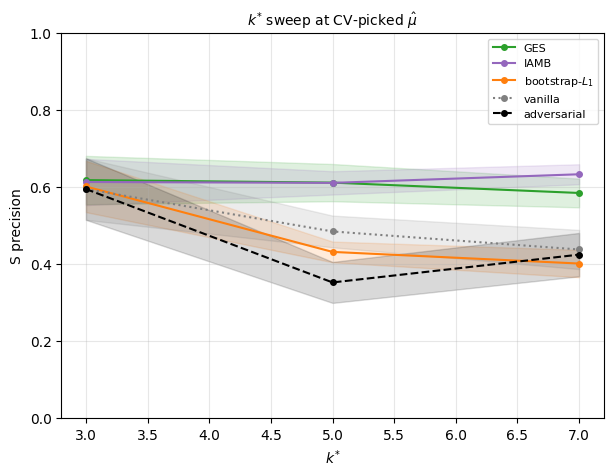

In [10]:
viz.plot_recovery_cv_vs_axis(k_cv, axis_col='k_star')

## Noise scale (SNR)

$\sigma_\mathrm{noise} \in \{0.5, 1.0, 2.0\}$ at the anchor, `S_precision`. The expectation was that the prior helps more at low SNR (high $\sigma$). Instead the gap is flat to peaked: GES minus vanilla is +0.04, +0.13, +0.08 across $\sigma$, peaking at the default $\sigma=1.0$. The effect is present but not amplified by noise in this range.

<Axes: title={'center': '$\\sigma_{\\mathrm{noise}}$ sweep at CV-picked $\\hat{\\mu}$'}, xlabel='$\\sigma_{\\mathrm{noise}}$', ylabel='S precision'>

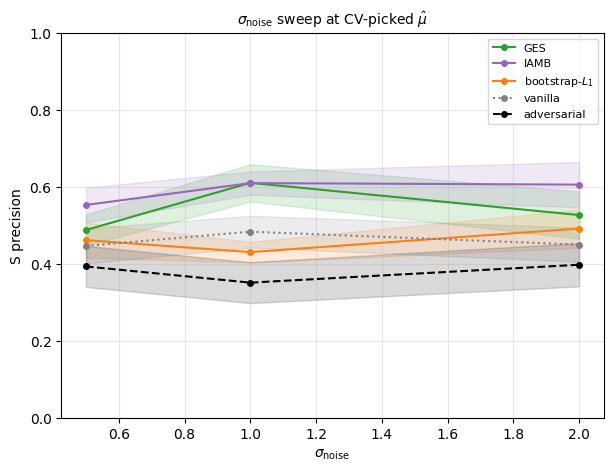

In [11]:
viz.plot_recovery_cv_vs_axis(noise_cv, axis_col='noise_scale')

## Soft prior vs hard pre-selection

For each $q$ source, the soft penalty at $\mu_\mathrm{rel}=1$ against hard pre-selection at thresholds $t \in \{0.3, 0.5, 0.7\}$, as a function of $p_\mathrm{edge}$, `S_precision`. The best hard threshold changes with $p_\mathrm{edge}$, so hard pre-selection needs tuning per regime; the soft prior does not.

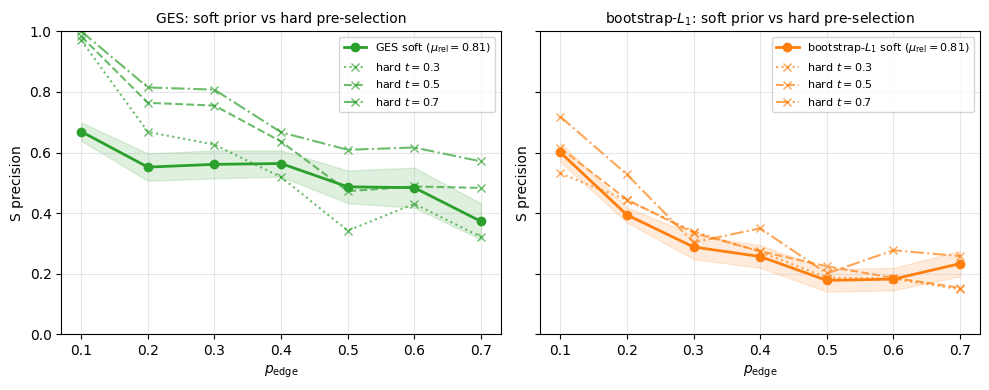

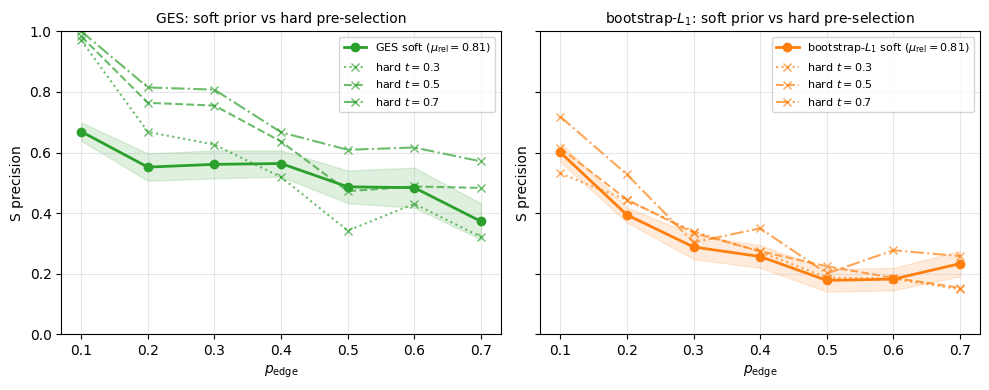

In [12]:
viz.plot_soft_vs_hard_facet(pe_sweep, q_sources=['ges', 'bootstrap_l1'], ncols=2)

## K-ablation

Anchor cell $p=30, n=300, k^*=5, p_\mathrm{edge}=0.2$, 20 seeds, $K \in \{k^*, 1.5 k^*, 2 k^*, 3 k^*\}$. CV picks $\hat{\mu}$ per (cell, $K$, $q$ source) on log-loss; `S_precision` is scored against $S^*$. Checks whether the effect holds when the budget is tighter or looser than the headline $K = 2 k^*$.

<Axes: title={'center': '$K / k^{*}$ sweep at CV-picked $\\hat{\\mu}$'}, xlabel='$K / k^{*}$', ylabel='S precision'>

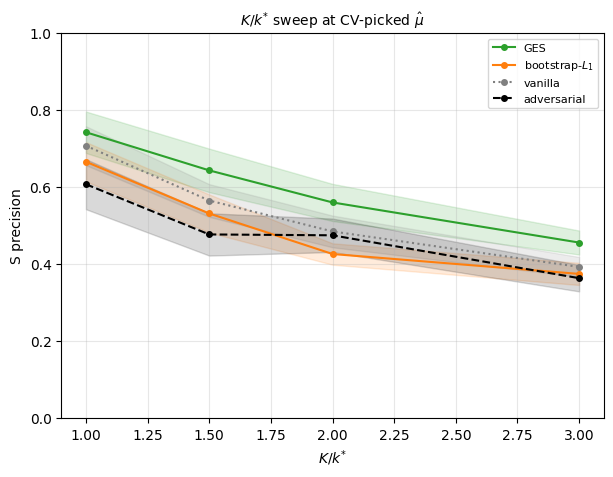

In [13]:
k_abl = load_recovery_csvs(ROOT / 'results/causal_prior/synthetic/recovery_p30_K_ablation')
k_abl = k_abl[~k_abl['q_source'].str.startswith('pc')]
k_abl = k_abl[k_abl['q_source'] != 'oracle']
viz.plot_recovery_cv_vs_axis(k_abl, axis_col='K_multiplier')

GES minus vanilla (`S_precision`) is +0.04 at $K=k^*$, +0.08 at $1.5 k^*$, +0.08 at $2 k^*$, +0.06 at $3 k^*$. At $K=k^*$ there is little headroom, since FR already fills the budget with the strongest, mostly causal features; the effect appears once $K \geq 1.5 k^*$ adds spare slots, and is roughly flat across the larger budgets. The headline $K = 2 k^*$ is representative. `causal_precision` agrees the tight budget has no room: +0.00 at $K=k^*$, rising to +0.06 to +0.08 for $K \geq 1.5 k^*$.

## Alternative criterion: CV on stability

CV on log-loss picks $\hat{\mu}$ to minimize held-out loss. At high $p_\mathrm{edge}$ this can favor small $\hat{\mu}$, because confounders are predictive and log-loss uses them. CV on stability picks $\hat{\mu}$ to maximize mean pairwise Jaccard of the selected supports across folds, which rewards features whose selection is stable under data perturbation. Sweep on the $p_\mathrm{edge}$ axis only, same anchor cell as the headline.

In [14]:
cv_stab = load_recovery_csvs(ROOT / 'results/causal_prior/synthetic/recovery_p30_headline_cv_stability')
cv_stab = cv_stab[~cv_stab['q_source'].str.startswith('pc')]
cv_stab = cv_stab[cv_stab['q_source'] != 'oracle']
pe_cv_stab = cv_stab[cv_stab['noise_scale'] == 1.0].query('p == 30 and n == 300 and k_star == 5')

<Axes: title={'center': '$p_{\\mathrm{edge}}$ sweep at CV-picked $\\hat{\\mu}$'}, xlabel='$p_{\\mathrm{edge}}$', ylabel='S precision'>

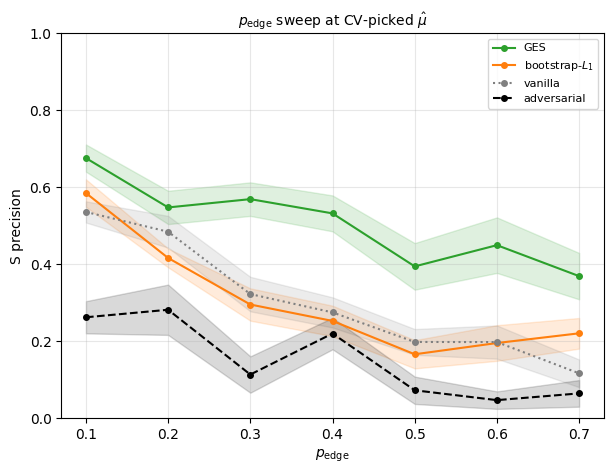

In [15]:
viz.plot_recovery_cv_vs_axis(pe_cv_stab, axis_col='p_edge')

<Axes: title={'center': 'CV-picked $\\mu$ vs $p_{\\mathrm{edge}}$'}, xlabel='$p_{\\mathrm{edge}}$', ylabel='$\\hat{\\mu}_{\\mathrm{rel}}$ (CV)'>

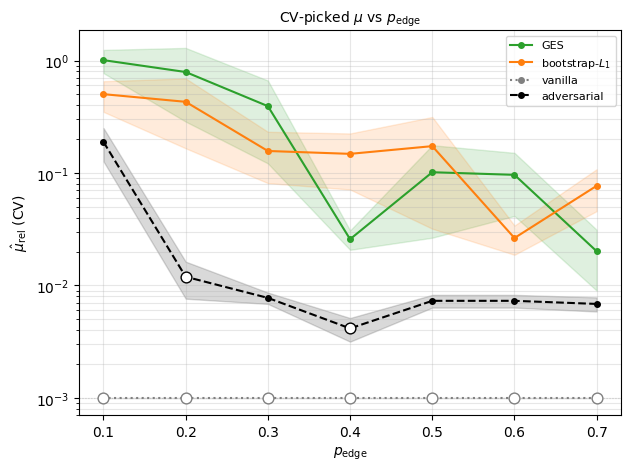

In [16]:
viz.plot_mu_star_vs_axis(pe_cv_stab, axis_col='p_edge')

Two differences from the log-loss headline, in `S_precision`.

First, stability CV raises $\hat{\mu}$ at low $p_\mathrm{edge}$ (GES median $\hat{\mu}_\mathrm{rel}=0.81$ at $p_\mathrm{edge}=0.1$, dropping to about 0.01 by $p_\mathrm{edge}\geq 0.3$) and gives a comparable GES advantage: GES minus vanilla is +0.14 at $p_\mathrm{edge}=0.1$ and +0.20 to +0.25 for $p_\mathrm{edge}\geq 0.3$, similar to log-loss CV.

Second, stability CV is not source-aware. Adversarial $q$ is switched on against the wrong features and `S_precision` drops by 0.27 at $p_\mathrm{edge}=0.1$ (negative across all $p_\mathrm{edge}$), while log-loss CV sets adversarial $\hat{\mu}$ to 0 and stays at the vanilla floor. Log-loss CV is self-correcting against an uninformative prior; stability CV only measures support agreement, which an adversarial $q$ can produce.

Takeaway: log-loss CV is the safer default; stability CV helps only when $q$ is known to be informative. Under either criterion the GES advantage is a low-density effect, so the $p=18$ TB regime stays open for §6.3.

## Orientation quality

q above scores adjacency to Y; this checks whether PC and GES recover the right edges and their orientation. Each true DAG is converted to its CPDAG (the most an observational method can recover) and the recovered CPDAG is scored against it, full sample, 20 seeds per density. Adjacency recall is how much of the skeleton is found; arrowhead F1 is how many found edges are oriented correctly (edges the data cannot orient are undirected in the truth too, so they are not penalized).

adjacency_recall adjacency_precision arrowhead_f1     shd
                          mean                mean         mean    mean
method p_edge                                                          
ges    0.1               0.958               0.730        0.688   29.00
       0.2               0.838               0.476        0.442  129.05
       0.3               0.745               0.410        0.311  221.65
       0.4               0.713               0.461        0.335  251.25
       0.5               0.682               0.525        0.330  274.55
       0.6               0.685               0.621        0.380  272.50
       0.7               0.663               0.689        0.368  291.70
pc     0.1               0.667               0.886        0.480   31.60
       0.2               0.293               0.777        0.201   86.65
       0.3               0.152               0.682        0.100  136.00
       0.4               0.096               0.691        0.073  177.75
       0.5               0.068               0.733        0.047  221.35
       0.6               0.055               0.769        0.033  266.60
       0.7               0.041               0.804        0.021  309.10

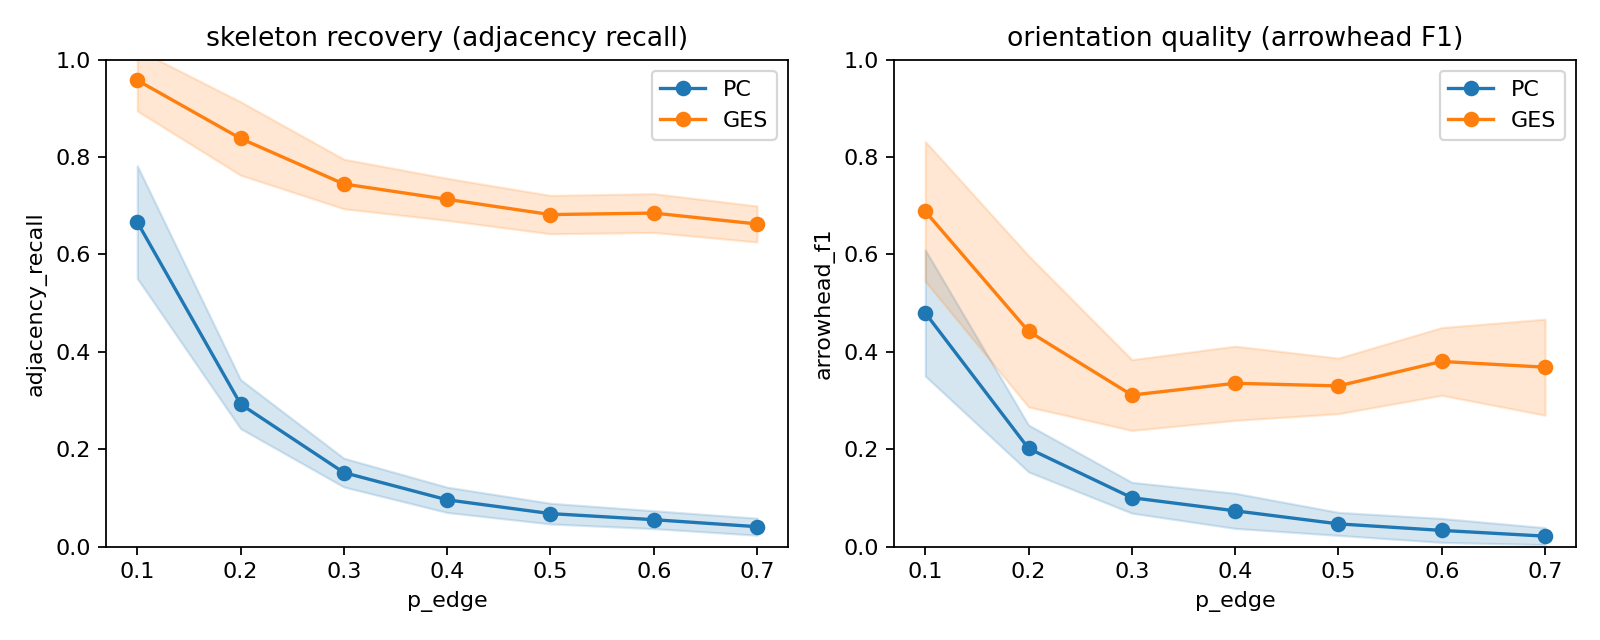

In [17]:
import pandas as pd
from IPython.display import Image, display

ORI = ROOT / 'results/causal_prior/synthetic/orientation/orientation_p_edge'
ori = pd.read_csv(ORI / 'summary.csv', header=[0, 1], index_col=[0, 1])
cols = [('adjacency_recall', 'mean'), ('adjacency_precision', 'mean'),
        ('arrowhead_f1', 'mean'), ('shd', 'mean')]
display(ori.loc[:, cols].round(3))
display(Image(filename=str(ORI / 'orientation_curves.png')))

## Scope: the positive result rests on GES

Of the five $q$ sources, the causal-vs-predictive separation is carried by GES alone. Oracle is a non-operational upper bound (dropped from the headlines); uniform is vanilla by construction; adversarial is a failure probe; bootstrap-$L_1$ is the predictive foil GES is measured against. PC, the other causal-discovery source, returns near-noise $q$ under Fisher-Z on these dense Gaussian DAGs and was omitted, so the one regime meant to be favorable to constraint-based discovery does not in fact support it.

We scope the §6.1 claim accordingly: under linear-Gaussian conditions a score-based causal source (GES) produces more causally selective $q$ than the predictive baseline, and the soft prior converts that selectivity into support recovery. We do not claim causal $q$ beats predictive $q$ for every discovery method. The realized effect tracks the selectivity $\bar q_C / \bar q_{S^*}$ of whichever source is used, not causal provenance as such. Broadening this needs a second surviving causal source (or a faster PC backend that restores its selectivity); absent that, the result is reported as GES-on-Gaussian.